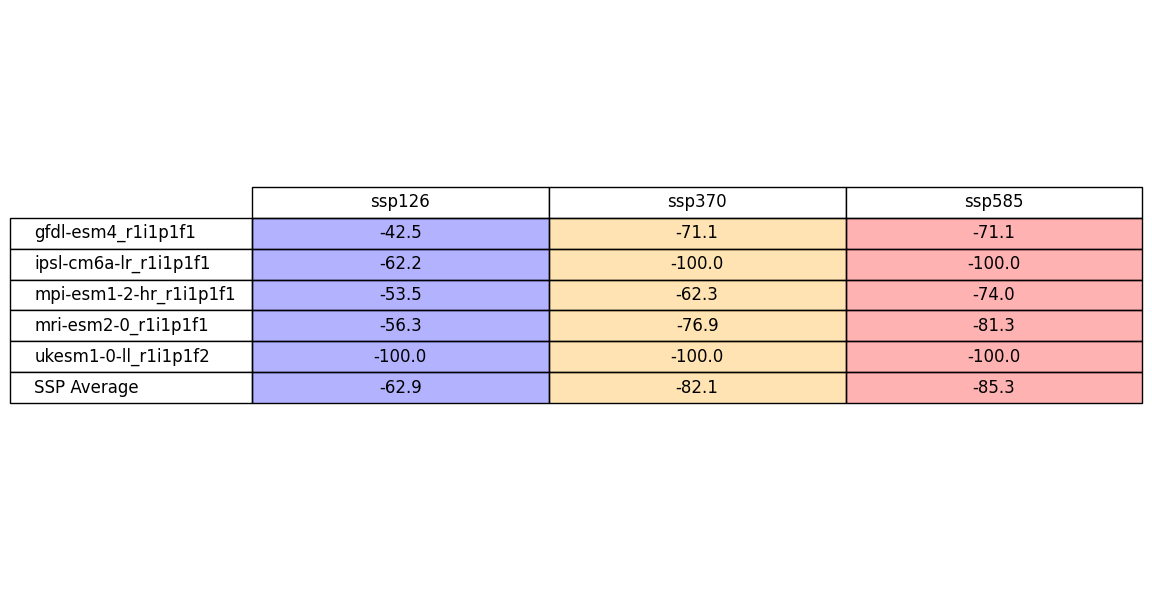

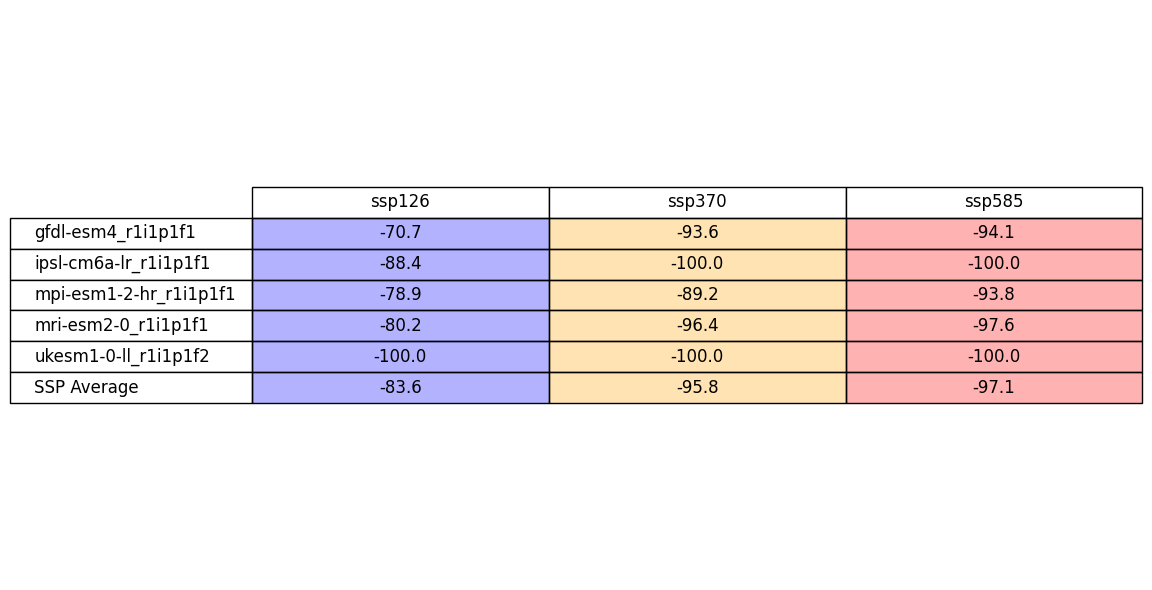

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

# Load the GCM and SSP-specific results from the CSV file
results = pd.read_csv('GCM_SSP_Results_2100.csv')

# Pivot the DataFrame for area and volume loss
area_loss_table = results.pivot(index='GCM', columns='Scenario', values='Area Relative to 2020 (%)')
volume_loss_table = results.pivot(index='GCM', columns='Scenario', values='Volume Relative to 2020 (%)')

# Calculate the average for each SSP (across GCMs)
ssp_averages_area = area_loss_table.mean().round(1)
ssp_averages_volume = volume_loss_table.mean().round(1)

# Add the SSP averages as a new row to the tables
area_loss_table.loc['SSP Average'] = ssp_averages_area
volume_loss_table.loc['SSP Average'] = ssp_averages_volume

# Add a title for the GCM column
area_loss_table.index.name = 'GCM'
volume_loss_table.index.name = 'GCM'

# Define the color dictionary for scenarios
color_dict = {'ssp126': 'blue', 'ssp370': 'orange', 'ssp585': 'red'}

# Function to plot a table
def plot_table(data):
    # Create a color map for the table with alpha
    cell_colors = []
    for idx, row in data.iterrows():
        row_colors = []
        for col in data.columns:
            # Apply alpha to scenario colors (same for all rows, including SSP Average)
            row_colors.append(to_rgba(color_dict[col], alpha=0.3))  # Alpha set to 0.3
        cell_colors.append(row_colors)

    # Plot the table
    fig, ax = plt.subplots(figsize=(12, 6))  # Adjust the size as needed
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(
        cellText=data.values,
        rowLabels=data.index,
        colLabels=data.columns,
        loc='center',
        cellLoc='center',
        cellColours=cell_colors
    )

    # Adjust table style
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.5)

    plt.tight_layout()
    plt.show()

# Plot the area loss table
plot_table(area_loss_table)

# Plot the volume loss table
plot_table(volume_loss_table)